In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)
y_valid = torch.FloatTensor(y_valid).view(-1, 1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

In [5]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [6]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

device

'cpu'

In [14]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {
        'loss': [],
        'train_metric': [],
        'valid_metric': [],
    }
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            # for group in optimizer.param_groups:
            #     for p in group['params']:
            #         if p.grad is not None:
            #             print(f'\t{p.grad.max()}')
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        
        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)

        avg_metric_train = metric.compute().item()
        history['train_metric'].append(avg_metric_train)


        model.eval()
        metric.reset()
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                y_pred = model(X_batch)
                metric.update(y_pred, y_batch)
        
        avg_metric_valid = metric.compute().item()
        history['valid_metric'].append(avg_metric_valid)


        print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)
    return history

def plot_history(history, n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 1.314, Train Metric: 0.902, Valid Metric: 0.885
Epoch: 2/20, Loss: 1.234, Train Metric: 0.876, Valid Metric: 0.87
Epoch: 3/20, Loss: 1.064, Train Metric: 0.812, Valid Metric: 0.75
Epoch: 4/20, Loss: 0.791, Train Metric: 0.691, Valid Metric: 0.637
Epoch: 5/20, Loss: 0.633, Train Metric: 0.603, Valid Metric: 0.6
Epoch: 6/20, Loss: 0.588, Train Metric: 0.572, Valid Metric: 0.579
Epoch: 7/20, Loss: 0.565, Train Metric: 0.558, Valid Metric: 0.567
Epoch: 8/20, Loss: 0.548, Train Metric: 0.547, Valid Metric: 0.544
Epoch: 9/20, Loss: 0.534, Train Metric: 0.538, Valid Metric: 0.537
Epoch: 10/20, Loss: 0.522, Train Metric: 0.531, Valid Metric: 0.532
Epoch: 11/20, Loss: 0.511, Train Metric: 0.525, Valid Metric: 0.518
Epoch: 12/20, Loss: 0.501, Train Metric: 0.518, Valid Metric: 0.517
Epoch: 13/20, Loss: 0.494, Train Metric: 0.514, Valid Metric: 0.53
Epoch: 14/20, Loss: 0.488, Train Metric: 0.51, Valid Metric: 0.543
Epoch: 15/20, Loss: 0.482, Train Metric: 0.507, Valid Metric: 0

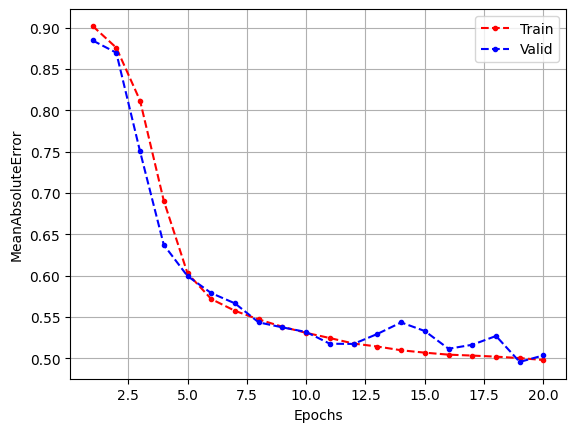

In [15]:
learning_rate = 0.01
n_epochs = 20

model = nn.Sequential(
    nn.Linear(in_features=8, out_features=30), nn.Sigmoid(),
    nn.Linear(in_features=30, out_features=50), nn.Sigmoid(),
    nn.Linear(in_features=50, out_features=1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError()

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs)

In [16]:
model.eval()
metric.reset()

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        metric.update(y_pred, y_batch)

avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test, 3)}')

Test Metric: 0.499


In [17]:
model.eval()

X_new, y_new = next(iter(test_loader))

with torch.inference_mode():
	y_pred = model(X_new)

y_pred[:5]

tensor([[3.0285],
        [1.6047],
        [5.8582],
        [2.9299],
        [2.5369]])

In [18]:
y_test[:5]

tensor([[4.4470],
        [1.4270],
        [5.0000],
        [2.5970],
        [2.4690]])

In [19]:
sum([param.numel() for param in model.parameters()])

1871

<div style='padding-left: 2em; color: #8eb8e3'>

<div style='color: white'>

1. First layer: Linear(8, 30)
</div>
weights: 8×30=240
bias: 30

👉 total = 270

<div style='color: white'>

2. Second layer: Linear(30, 50)
</div>
weights: 30×50=1500
bias: 50

👉 total = 1550

<div style='color: white'>

3. Third layer: Linear(50, 1)
</div>
weights: 50×1=50
bias: 1

👉 total = 51
</div>